In [1]:
pwd

'/home/jovyan/dev/dea-notebooks/Claire/CoastInsights'

In [2]:
import geopandas as gpd

import fiona

import matplotlib.pyplot as plt
import pandas as pd

# Load Coastal Compartments to regionalise the Smartline gap analysis

In [68]:
#List all layers in the target geodatabase

layers = fiona.listlayers("/gdata1/data/coastal_compartments/CoastalCompartments_v3.gdb")

print (layers)

['Divisions', 'Primary_points', 'Realms', 'Regions', 'Secondary_points', 'Primary_compartments', 'Secondary_compartments']


In [79]:
# divisions = gpd.read_file("/gdata1/data/coastal_compartments/CoastalCompartments_v3.gdb", layer='Divisions')
Realms = gpd.read_file("/gdata1/data/coastal_compartments/CoastalCompartments_v3.gdb", layer='Realms')

In [80]:
Realms

,ID_Realm,Description,Shape_Length,Shape_Area,geometry
0,1,Tropical; Tide-dominated,119.184172,204.362748,"MULTIPOLYGON (((146.53427 -14.41466, 147.00819..."
1,2,Temperate; Wave-dominated,156.960476,222.783857,"MULTIPOLYGON (((115.59005 -27.23561, 117.94571..."


<Axes: >

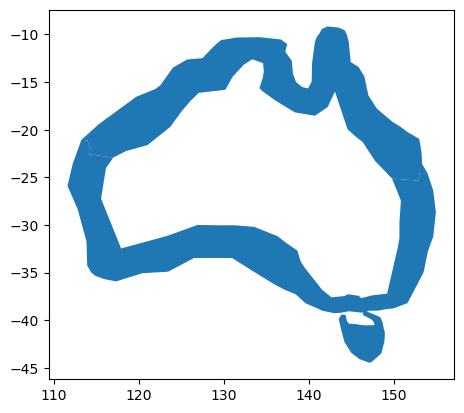

In [78]:
Realms.plot()

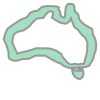

In [86]:
# Combine sedimentary compartments realms layer into single coastal polygon of buffered Australian coastline
coastalzone = Realms.union_all()
coastalzone

## Load Smartline

In [3]:
layers = fiona.listlayers("/gdata1/data/smartline/Smartline.gpkg")

print (layers)

['Smartline100K']


In [4]:
smartline = gpd.read_file("/gdata1/data/smartline/Smartline.gpkg")

In [8]:
smartline.head()

,OBJECTID,BASELINE,BASESCALE,BASEFEAT,AUSCSTFID,UPDATED,ABSAMP_ID,BACKPROX_N,BACKPROX_V,BACKPROX_R,...,UNDFROCK_L,CORAL_N,CORAL_V,CORAL_L,UNCLASS_N,UNCLASS_V,UNCLASS_L,COMMENTS,Shape_Length,geometry
0,1,235,25K,Mean High Water Mark (MHWM),206271,2009-06-26 00:00:00+00:00,nsw323,113222,Hard bedrock cliffs (>5m),138,...,Not a known undif rock shore,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.000113,"LINESTRING (151.26901 -33.90253, 151.2691 -33...."
1,2,235,25K,Mean High Water Mark (MHWM),206272,2009-06-26 00:00:00+00:00,nsw323,819090,Impermeable artificial structure,258,...,Not a known undif rock shore,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.000377,"LINESTRING (151.26842 -33.90362, 151.26847 -33..."
2,3,235,25K,Mean High Water Mark (MHWM),206273,2009-06-26 00:00:00+00:00,nsw323,819090,Impermeable artificial structure,258,...,Not a known undif rock shore,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.000869,"LINESTRING (151.26857 -33.90328, 151.26865 -33..."
3,4,235,25K,Mean High Water Mark (MHWM),206262,2009-06-26 00:00:00+00:00,nsw320B,813063,Vertical concrete structure,258,...,Not a known undif rock shore,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.002544,"LINESTRING (151.27698 -33.89159, 151.27734 -33..."
4,5,235,25K,Mean High Water Mark (MHWM),206263,2009-06-26 00:00:00+00:00,nsw320B,813063,Vertical concrete structure,258,...,Not a known undif rock shore,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.000233,"LINESTRING (151.27401 -33.89426, 151.27404 -33..."


In [5]:
smartline.columns

Index(['OBJECTID', 'BASELINE', 'BASESCALE', 'BASEFEAT', 'AUSCSTFID', 'UPDATED',
       'ABSAMP_ID', 'BACKPROX_N', 'BACKPROX_V', 'BACKPROX_R', 'BACKPROX_S',
       'BACKDIST_N', 'BACKDIST_V', 'BACKDIST_R', 'BACKDIST_S', 'BACKPROF_N',
       'BACKPROF_V', 'BACKPROF_R', 'BACKPROF_S', 'INTERTD1_N', 'INTERTD1_V',
       'INTERTD1_R', 'INTERTD1_S', 'INTERTD2_N', 'INTERTD2_V', 'INTERTD2_R',
       'INTERTD2_S', 'INTSLOPE_N', 'INTSLOPE_V', 'INTSLOPE_R', 'INTSLOPE_S',
       'SUBTID1_N', 'SUBTID1_V', 'SUBTID1_R', 'SUBTID1_S', 'SUBTID2_N',
       'SUBTID2_V', 'SUBTID2_R', 'SUBTID2_S', 'EXPOSURE_N', 'EXPOSURE_V',
       'EXPOSURE_R', 'EXPOSURE_S', 'GEOLOGY1_N', 'GEOLOGY1_V', 'GEOLOGY1_R',
       'GEOLOGY1_S', 'GEOLOGY2_N', 'GEOLOGY2_V', 'GEOLOGY2_R', 'GEOLOGY2_S',
       'MUDDY_N', 'MUDDY_V', 'MUDDY_L', 'SANDY_N', 'SANDY_V', 'SANDY_L',
       'DUNES_N', 'DUNES_V', 'DUNES_L', 'COARSED_N', 'COARSED_V', 'COARSED_L',
       'UNDIFSED_N', 'UNDIFSED_V', 'UNDIFSED_L', 'SOFTROCK_N', 'SOFTROCK_V',
       

# Read in the GEODATA_COAST_100k dataset.
# Create state bounding boxes, removing overlaps, to ensure that offshore areas are included in state boundaries.
# Warning - this used a non-authoritative offshore boundary. This dataset is intended to capture coasts not deep offshore areas!

In [48]:
boundaries = gpd.read_file('~/gdata1/data/boundaries/GEODATA_COAST_100K/australia/cstauscd_r.shp')

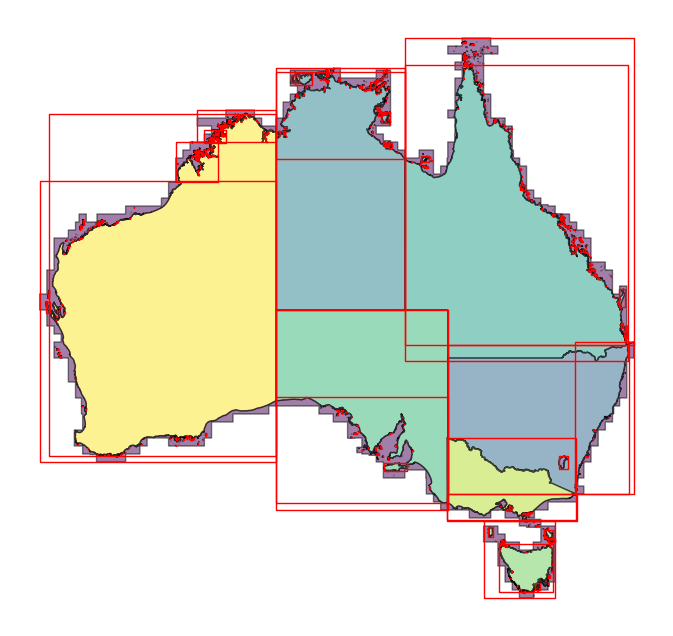

In [306]:
bbox_gdf = boundaries.copy()
bbox_gdf['geometry'] = boundaries.envelope

fig, ax = plt.subplots(figsize=(10, 8))
boundaries.plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.5)
bbox_gdf.boundary.plot(ax=ax, color='red', linewidth=1)

# for idx, row in boundaries.iterrows():
#     minx, miny, maxx, maxy = row.geometry.bounds
#     ax.text(maxx, maxy, row['STATE_CODE'], fontsize=8, color='red')  # swap column name as needed


ax.set_axis_off()
plt.show()

In [120]:
sorted_bbox = bbox_gdf.sort_values('AREA', ascending=False)
sortedclipped_bbox = sorted_bbox.loc[sorted_bbox['AREA'].where(sorted_bbox['AREA']>1).dropna().index]
sortedclipped_bbox


# smartline.loc[unclass.dropna().index]

,AREA,PERIMETER,CSTAUSCD_,CSTAUSCD_I,FEAT_CODE,ISLAND_NAM,GROUP_NAME,STATE_CODE,Q_INFO,UFI,geometry
1409,227.390776,137.952652,1411,7,mainland,None,None,9,AE001501,AE00051131,"POLYGON ((113.15636 -35.13485, 129.00193 -35.1..."
418,151.674350,96.398617,420,420,mainland,None,None,5,AE000640,AE00022909,"POLYGON ((137.99467 -29.17858, 153.55184 -29.1..."
545,115.081815,79.214192,547,49,mainland,None,None,4,AE001127,AE00031788,"POLYGON ((129.00048 -25.99862, 137.99906 -25.9..."
6088,91.762948,67.724474,6090,2,mainland,None,None,6,AE000845,AE00010113,"POLYGON ((129.00126 -38.06128, 141.00289 -38.0..."
6350,76.645303,64.990884,6352,3,mainland,None,None,3,AE000704,AE00008139,"POLYGON ((140.99928 -37.50528, 153.63834 -37.5..."
6858,22.942117,44.762270,6860,2,mainland,None,None,8,AE000902,AE00006367,"POLYGON ((140.96179 -39.13719, 149.97651 -39.1..."
0,18.275141,176.631912,2,2,sea,None,None,0,AE001601,AE00022910,"POLYGON ((137.99467 -28.1672, 154.00106 -28.16..."
4478,17.217559,140.503624,4480,2593,sea,None,None,0,AE001500,AE00051132,"POLYGON ((112.50139 -35.49881, 129.00142 -35.4..."
6498,9.808104,71.372668,6500,3,sea,None,None,0,AE000844,AE00010114,"POLYGON ((129.00126 -38.49854, 141.0014 -38.49..."
473,9.411271,122.631367,475,2,sea,None,None,0,AE001126,AE00031789,"POLYGON ((129.00124 -16.53868, 138.00118 -16.5..."


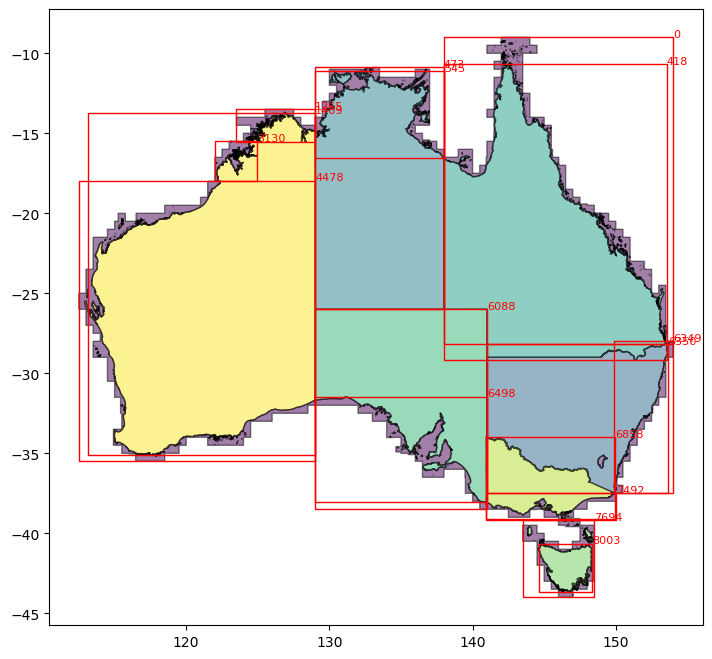

In [181]:
fig, ax = plt.subplots(figsize=(10, 8))
sortedclipped_bbox.boundary.plot(ax=ax, color='red', linewidth=1)
boundaries.plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.5)
# sortedclipped_bbox.boundary.where(sortedclipped_bbox['AREA']==18.275141).plot(edgecolor='black', linewidth=2)

for idx, row in sortedclipped_bbox.iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    ax.text(maxx, maxy, idx, fontsize=8, color='red')  # swap column name as needed

In [245]:
# merge qld terrestrial and offshore polygon areas (offshore is a bbox of the terrestrial area. It is NOT authoritative)
qld = sortedclipped_bbox.loc[[0,418]]
qld = qld.geometry.union_all()
qld = gpd.GeoDataFrame(geometry=[qld], crs=sortedclipped_bbox.crs)
# Remove overlapping state offshore areas
qld = qld.difference(sortedclipped_bbox.loc[[6349]], align=False)
qld = qld.difference(sortedclipped_bbox.loc[[6088]], align=False)
qld = qld.difference(boundaries.where(boundaries['STATE_CODE']==3).union_all(), align=False)
qld = qld.union(boundaries.where(boundaries['STATE_CODE']==5).union_all())

In [290]:
nsw = sortedclipped_bbox.loc[[6349, 6350]]
nsw = nsw.geometry.union_all()
nsw = gpd.GeoDataFrame(geometry=[nsw], crs=sortedclipped_bbox.crs)
# Tidy up using terrestrial state boundaries
nsw = nsw.difference(boundaries.where(boundaries['STATE_CODE']==5).union_all(), align=False)
nsw = nsw.difference(boundaries.where(boundaries['STATE_CODE']==8).union_all(), align=False)
nsw = nsw.difference(boundaries.where(boundaries['STATE_CODE']==6).union_all(), align=False)

In [202]:
tas = sortedclipped_bbox.loc[[7694]]

In [281]:
vic = sortedclipped_bbox.loc[[6858, 7492]]
vic = vic.geometry.union_all()
vic = gpd.GeoDataFrame(geometry=[vic], crs=sortedclipped_bbox.crs)
# Tidy up using terrestrial boundaries
vic = vic.difference(boundaries.where(boundaries['STATE_CODE']==3).union_all(), align=False)
vic = vic.difference(boundaries.where(boundaries['STATE_CODE']==2).union_all(), align=False)
vic = vic.difference(boundaries.where(boundaries['STATE_CODE']==1).union_all(), align=False)
vic = vic.difference(nsw)

In [207]:
sa = sortedclipped_bbox.loc[[6088, 6498]]
sa = sa.geometry.union_all()
sa = gpd.GeoDataFrame(geometry=[sa], crs=sortedclipped_bbox.crs)

In [210]:
nt= sortedclipped_bbox.loc[[545, 473]]
nt = nt.geometry.union_all()
nt = gpd.GeoDataFrame(geometry=[nt], crs=sortedclipped_bbox.crs)

In [213]:
wa= sortedclipped_bbox.loc[[1409,4478,1265]]
wa = wa.geometry.union_all()
wa = gpd.GeoDataFrame(geometry=[wa], crs=sortedclipped_bbox.crs)

In [296]:
# Combine into single dataframe

state_coast_boundaries = pd.concat([wa,nt,sa,tas,vic,nsw,qld], ignore_index=True)
state_coast_boundaries = gpd.GeoDataFrame(state_coast_boundaries, crs=wa.crs)

# Format the dataframe
state_coast_boundaries['geometry'] = state_coast_boundaries['geometry'].fillna(state_coast_boundaries[0])
state_coast_boundaries = state_coast_boundaries[['geometry']]

state_coast_boundaries

,geometry
0,"POLYGON ((129.00142 -35.49881, 112.50139 -35.4..."
1,"POLYGON ((137.99906 -25.99862, 129.00048 -25.9..."
2,"POLYGON ((141.0014 -38.49854, 129.00126 -38.49..."
3,"POLYGON ((143.50138 -43.99852, 148.50137 -43.9..."
4,"POLYGON ((140.96179 -39.13719, 140.96179 -33.9..."
5,"MULTIPOLYGON (((141.08261 -28.99909, 141.16593..."
6,"POLYGON ((154.00106 -8.99852, 154.00106 -27.99..."


In [339]:
labels = ['wa','nt','sa','tas','vic','nsw','qld']
state_coast_boundaries['name'] = labels
state_coast_boundaries

,geometry,name
0,"POLYGON ((129.00142 -35.49881, 112.50139 -35.4...",wa
1,"POLYGON ((137.99906 -25.99862, 129.00048 -25.9...",nt
2,"POLYGON ((141.0014 -38.49854, 129.00126 -38.49...",sa
3,"POLYGON ((143.50138 -43.99852, 148.50137 -43.9...",tas
4,"POLYGON ((140.96179 -39.13719, 140.96179 -33.9...",vic
5,"MULTIPOLYGON (((141.08261 -28.99909, 141.16593...",nsw
6,"POLYGON ((154.00106 -8.99852, 154.00106 -27.99...",qld


<Axes: >

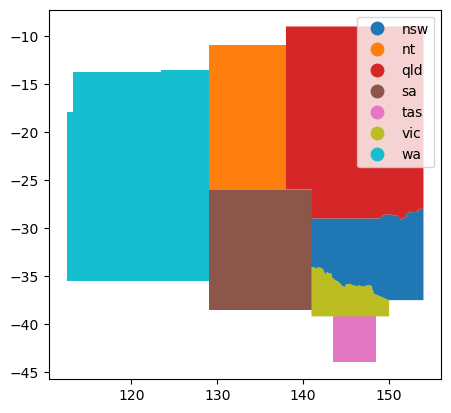

In [340]:
state_coast_boundaries.plot(column='name', legend=True)

In [341]:
# Export to geojson
# state_coast_boundaries.to_file('~/gdata1/data/boundaries/GEODATA_COAST_100K/state_coast_boundaries', driver='GeoJSON')

<Axes: >

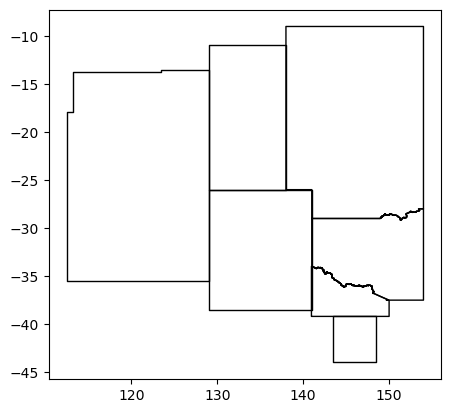

In [301]:
state_coast_boundaries.plot(edgecolor='black',facecolor='none')

# nt.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2, zorder=2)

<Axes: >

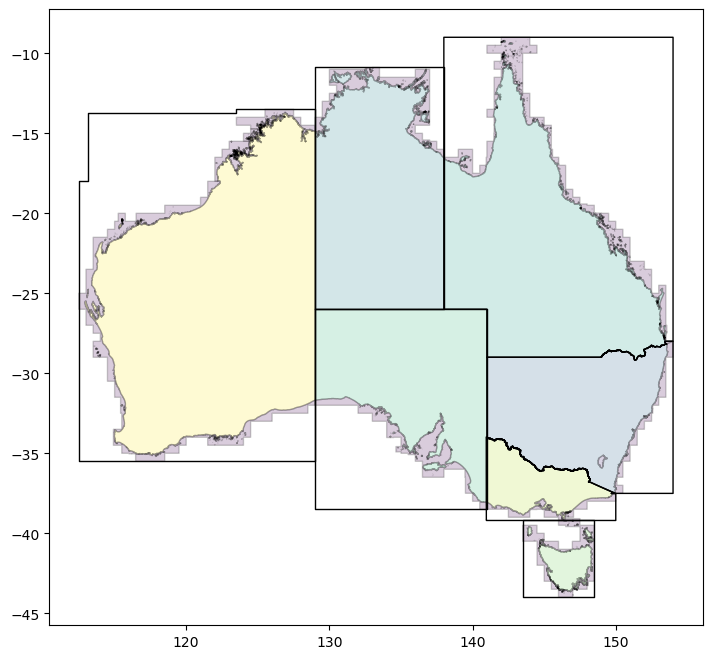

In [305]:
fig, ax = plt.subplots(figsize=(10, 8))
# sortedclipped_bbox.boundary.loc[[1409,4478,1265]].plot(ax=ax, color='red', linewidth=1)
# boundaries.where(boundaries['STATE_CODE']==6).plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.5, zorder=10)
boundaries.plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.2)
state_coast_boundaries.plot(ax=ax, edgecolor='black',facecolor='none',zorder=2)

# # sortedclipped_bbox.boundary.loc[[545, 473]].plot(ax=ax, edgecolor='black', linewidth=2)
# nt.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2, zorder=2)
# wa.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=2, zorder=2)
# sa.plot(ax=ax, edgecolor='yellow', facecolor='none', linewidth=2, zorder=2)
# vic.plot(ax=ax, edgecolor='darkgray', facecolor='none', linewidth=2, zorder=2)
# tas.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2, zorder=2)
# nsw.plot(ax=ax, edgecolor='orange', facecolor='none', linewidth=2, zorder=2)
# qld.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=2, zorder=2)


# Search Smartline for data gaps

In [315]:
# Check that the CRS is the same
state_coast_boundaries.crs == smartline.crs

True

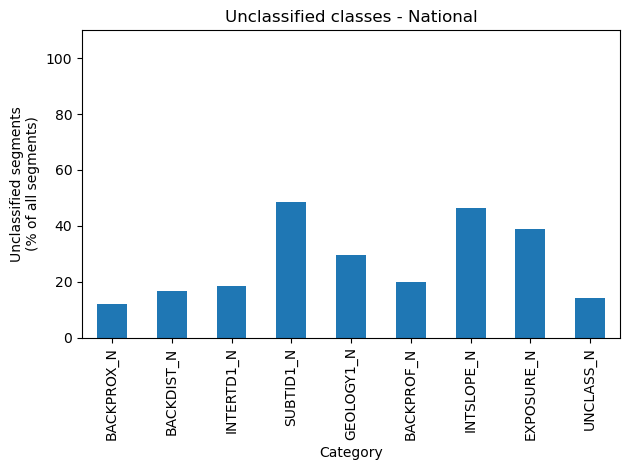

In [364]:
# count number of unclassified classes in Smartline (national summary)
unclassified_N = []

onedigit = ['UNCLASS_N']
threedigit = ['BACKPROF_N','INTSLOPE_N','EXPOSURE_N']
sixdigit = ['BACKPROX_N', 'BACKDIST_N', 'INTERTD1_N', 'SUBTID1_N', 'GEOLOGY1_N']#'INTERTD2_N','SUBTID2_N',, 'GEOLOGY2_N'

for name in sixdigit:
    count = smartline[name].where(smartline[name]=='909090').count()
    count=count/len(smartline)*100
    unclassified_N.append([name, count])

for name in threedigit:
    count = smartline[name].where(smartline[name]=='900').count()
    count=count/len(smartline)*100
    unclassified_N.append([name, count])

for name in onedigit:
    count = smartline[name].where(smartline[name]=='100').count()
    count=count/len(smartline)*100
    unclassified_N.append([name, count])

# unclassified_N

labels = list(x[0] for x in unclassified_N)
values = list(x[1] for x in unclassified_N)

pd.Series(values, index=labels).plot(kind='bar')
plt.xlabel('Category')
plt.ylim(0,110)

plt.ylabel('Unclassified segments\n(% of all segments)')
plt.title('Unclassified classes - National')
plt.tight_layout()
plt.savefig(f'Unclassified_segment_classes_National.png')
plt.show()

In [316]:
# Compare data gaps by State

In [342]:
matched_list = []

for idx, row in state_coast_boundaries.iterrows():
    polygon = row.geometry
    subset = smartline[smartline.within(polygon)].copy()
    subset['state_name'] = row['name'] 
    matched_list.append(subset)

points_within = pd.concat(matched_list, ignore_index=True)
points_within = gpd.GeoDataFrame(points_within, crs=smartline.crs)

In [343]:
points_within.head()

,OBJECTID,BASELINE,BASESCALE,BASEFEAT,AUSCSTFID,UPDATED,ABSAMP_ID,BACKPROX_N,BACKPROX_V,BACKPROX_R,...,CORAL_N,CORAL_V,CORAL_L,UNCLASS_N,UNCLASS_V,UNCLASS_L,COMMENTS,Shape_Length,geometry,state_name
0,58160,234,25K-100K,Mean High Water Mark (MHWM),632804,2009-06-26 00:00:00+00:00,,601014,Saltpans or saline mudflats,94,...,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.000345,"LINESTRING (117.54789 -20.72318, 117.54812 -20...",wa
1,58161,234,25K-100K,Mean High Water Mark (MHWM),632805,2009-06-26 00:00:00+00:00,,601014,Saltpans or saline mudflats,94,...,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.000178,"LINESTRING (117.95198 -20.52044, 117.95194 -20...",wa
2,58163,234,25K-100K,Mean High Water Mark (MHWM),632808,2009-06-26 00:00:00+00:00,,601014,Saltpans or saline mudflats,98,...,000,Not identified as a coral coast,Not a known coral coast,100,Stability unclassified,Stability unclassified,,0.000173,"LINESTRING (116.83705 -20.46259, 116.83722 -20...",wa
3,58165,234,25K-100K,Mean High Water Mark (MHWM),632811,2009-06-26 00:00:00+00:00,,601014,Saltpans or saline mudflats,98,...,000,Not identified as a coral coast,Not a known coral coast,100,Stability unclassified,Stability unclassified,,0.000355,"LINESTRING (116.83855 -20.45934, 116.83857 -20...",wa
4,58683,234,25K-100K,Mean High Water Mark (MHWM),632704,2009-06-26 00:00:00+00:00,,601014,Saltpans or saline mudflats,94,...,000,Not identified as a coral coast,Not a known coral coast,000,Shoreline stability classified,Stability classified,,0.214499,"LINESTRING (117.79229 -20.66937, 117.79303 -20...",wa


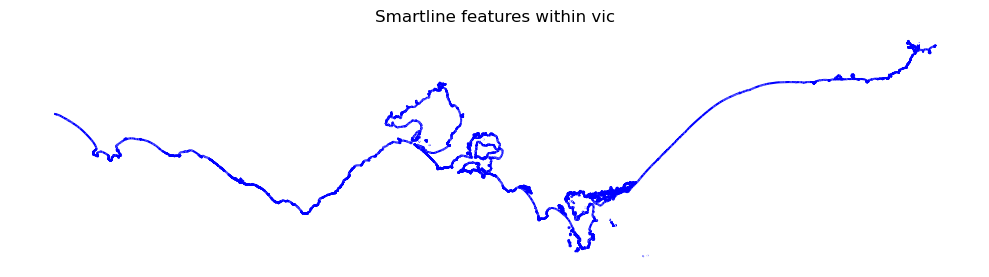

In [346]:
vic_points = points_within[points_within['state_name'] == 'vic']

fig, ax = plt.subplots(figsize=(10, 8))
vic_points.plot(ax=ax, color='blue', markersize=5)

ax.set_title('Smartline features within vic')
ax.set_axis_off()
plt.tight_layout()
plt.show()

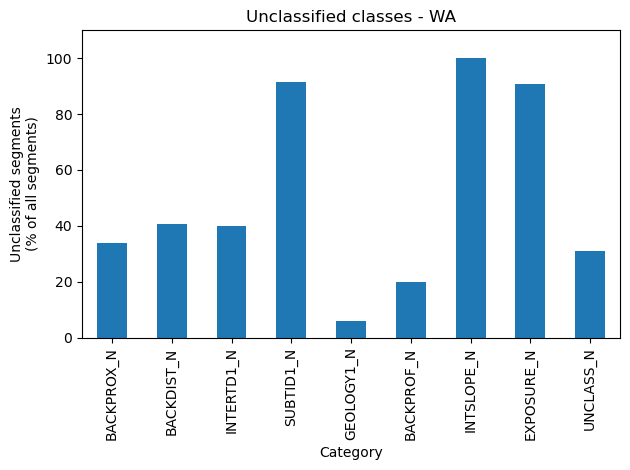

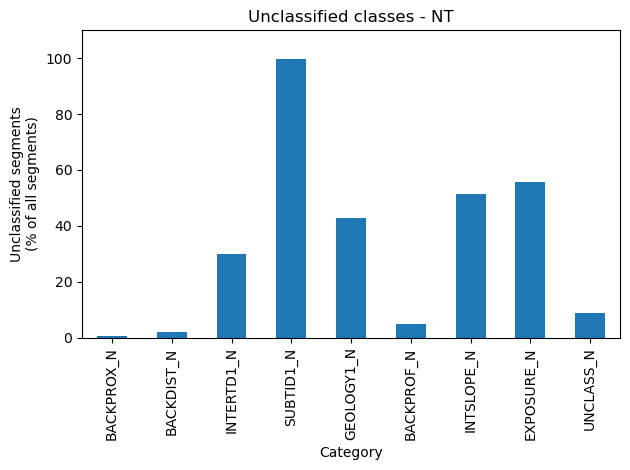

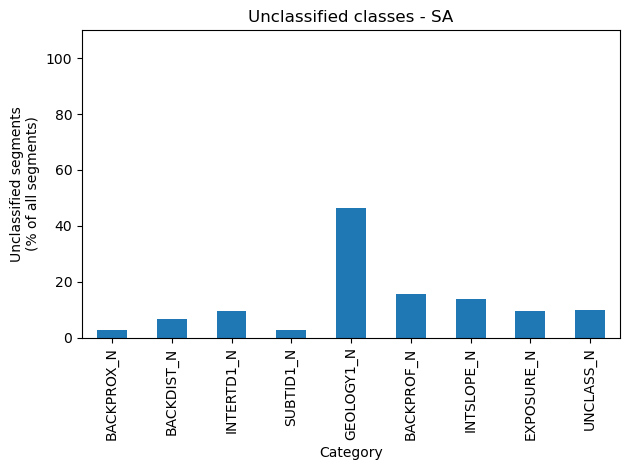

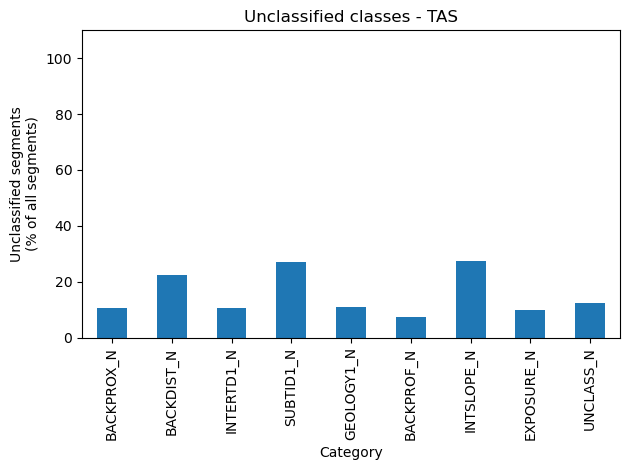

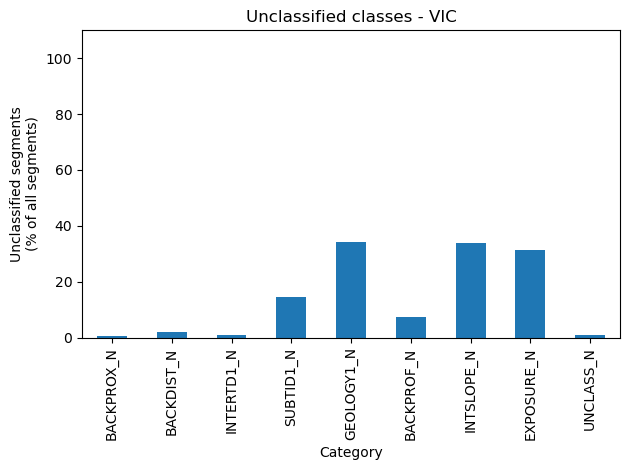

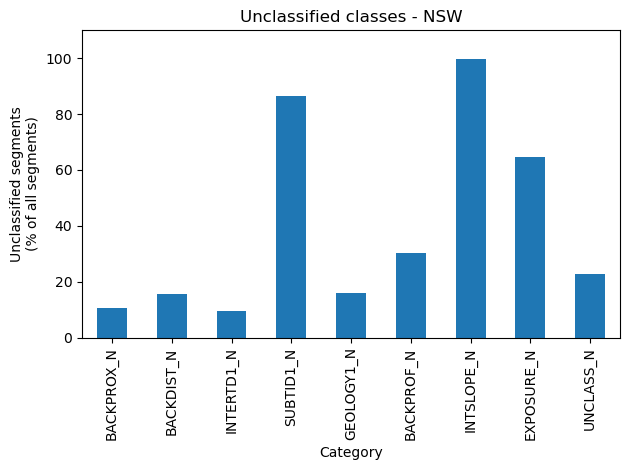

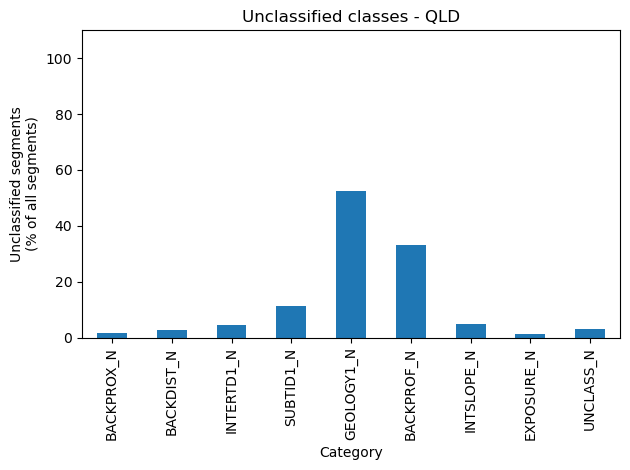

In [363]:
# Loop through states and plot unclassified data points

state_names = ['wa','nt','sa','tas','vic','nsw','qld']

onedigit = ['UNCLASS_N']
threedigit = ['BACKPROF_N','INTSLOPE_N','EXPOSURE_N']
sixdigit = ['BACKPROX_N', 'BACKDIST_N', 'INTERTD1_N', 'SUBTID1_N', 'GEOLOGY1_N']#'INTERTD2_N','SUBTID2_N',, 'GEOLOGY2_N'

for state in state_names:
    points = points_within[points_within['state_name'] == state]

    # count number of unclassified classes in Smartline (national summary)
    unclassified_N = [] 

    for name in sixdigit:
        count = points[name].where(points[name]=='909090').count()
        count=count/len(points)*100
        unclassified_N.append([name, count])
    
    for name in threedigit:
        count = points[name].where(points[name]=='900').count()
        count=count/len(points)*100
        unclassified_N.append([name, count])
    
    for name in onedigit:
        count = points[name].where(points[name]=='100').count()
        count=count/len(points)*100
        unclassified_N.append([name, count])
    
    # unclassified_N
    
    labels = list(x[0] for x in unclassified_N)
    values = list(x[1] for x in unclassified_N)
    
    pd.Series(values, index=labels).plot(kind='bar')
    plt.xlabel('Category')
    plt.ylim(0,110)
    plt.ylabel('Unclassified segments\n(% of all segments)')
    plt.title(f'Unclassified classes - {state.upper()}')
    plt.tight_layout()

    plt.savefig(f'Unclassified_segment_classes_{state}.png')
    # plt.close()
    plt.show()

In [347]:
labels

['wa', 'nt', 'sa', 'tas', 'vic', 'nsw', 'qld']